In [ ]:
# Homework 8

In [12]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/Users/keatondiehl/python_decal_fa25/course_assignments/homework8/state_data.csv')

In [4]:
df.shape
# 52 rows, 4 columns

(52, 4)

In [9]:
df.head()

,state,latitude,longitude,name
0,AK,63.588753,-154.493062,Alaska
1,AL,32.318231,-86.902298,Alabama
2,AR,35.201050,-91.831833,Arkansas
3,AZ,34.048928,-111.093731,Arizona
4,CA,36.778261,-119.417932,California


In [7]:
df.tail()

,state,latitude,longitude,name
47,VT,44.558803,-72.577841,Vermont
48,WA,47.751074,-120.740139,Washington
49,WI,43.784440,-88.787868,Wisconsin
50,WV,38.597626,-80.454903,West Virginia
51,WY,43.075968,-107.290284,Wyoming


In [ ]:
# columns represent a location (latitude/longitude) in each of the 50 states + territories
# First: Alaska
# Last: Wyoming
# 52 total entries
# Includes DC and Puerto Rico

In [19]:
median_latitude = df['latitude'].median()
print(median_latitude)
median_longitude = df['longitude'].median()
print(median_longitude)

39.4355155
-89.093198


In [23]:
df['dist_latitude'] = (df['latitude'] - median_latitude).abs()

df['dist_longitude'] = (df['longitude'] - median_longitude).abs()

df.shape

# 52 rows, 6 columns

(52, 7)

In [32]:
closest_latitude = df.loc[df['dist_latitude'].idxmin()]
farthest_latitude = df.loc[df['dist_latitude'].idxmax()]

closest_longitude = df.loc[df['dist_longitude'].idxmin()]
farthest_longitude = df.loc[df['dist_longitude'].idxmax()]

print(f"{closest_latitude['dist_latitude']:.2f}")
print(f"{farthest_latitude['dist_latitude']:.2f}")
print(f"{closest_longitude['dist_latitude']:.2f}")
print(f"{farthest_longitude['dist_latitude']:.2f}")

0.11
24.15
1.20
19.54


In [34]:
df.describe()
# I found it int the API reference section, listed in Computations / descriptive stats
# Generates descriptive statistics for the numerical columns in the DataFrame
# Helpful for getting a quick statistical summary of your data

,latitude,longitude,dist_latitued,dist_longitude,dist_latitude
count,52.000000,52.000000,52.000000,52.000000,52.000000
mean,39.153437,-92.824719,4.815714,14.535330,4.815714
std,6.967697,19.431647,4.998411,13.280351,4.998411
min,18.220833,-155.665857,0.114536,0.305330,0.114536
25%,35.438381,-102.009600,1.564952,6.037732,1.564952
50%,39.435516,-89.093198,3.890968,11.903743,3.890968
75%,43.220246,-78.291302,6.133912,17.832342,6.133912
max,63.588753,-66.590149,24.153237,66.572659,24.153237


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df = sns.load_dataset('planets')

In [59]:
df_cleaned = df.dropna(axis='rows')

In [63]:
df_cleaned.shape
# 496 rows, 6 columns

(498, 6)

In [65]:
df_cleaned.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [66]:
df_cleaned.tail()

,method,number,orbital_period,mass,distance,year
640,Radial Velocity,1,111.70000,2.100,14.90,2009
641,Radial Velocity,1,5.05050,1.068,44.46,2013
642,Radial Velocity,1,311.28800,1.940,17.24,1999
649,Transit,1,2.70339,1.470,178.00,2013
784,Radial Velocity,3,580.00000,0.947,135.00,2012


In [67]:
# Method, number (of planets), orbital period, masss, distance, year: method used to find exoplanets and then features of said planetary systems

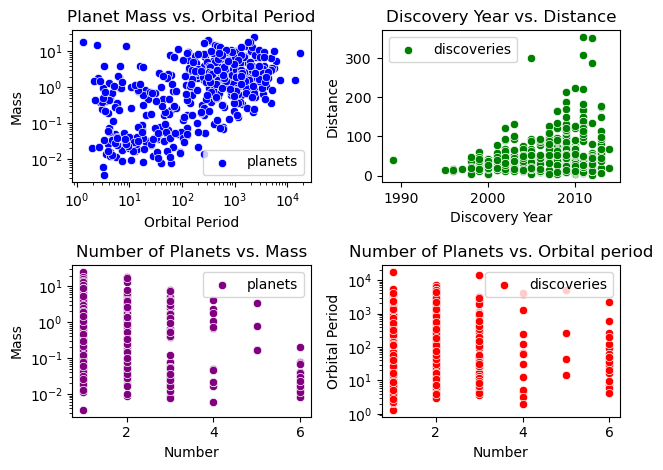

In [82]:

fig, axes = plt.subplots(2, 2)

sns.scatterplot(ax=axes[0, 0], data=df_cleaned, x='orbital_period', y='mass', color='blue', label='planets')
axes[0, 0].set_title('Planet Mass vs. Orbital Period')
axes[0, 0].set_xlabel('Orbital Period')
axes[0, 0].set_ylabel('Mass')
axes[0, 0].set_xscale('log') # Log scale for x-axis
axes[0, 0].set_yscale('log') # Log scale for y-axis
axes[0, 0].legend()

sns.scatterplot(ax=axes[0, 1], data=df_cleaned, x='year', y='distance', color='green', label='discoveries')
axes[0, 1].set_title('Discovery Year vs. Distance')
axes[0, 1].set_xlabel('Discovery Year')
axes[0, 1].set_ylabel('Distance')
axes[0, 1].legend()

sns.scatterplot(ax=axes[1, 0], data=df_cleaned, x='number', y='mass', color='purple', label='planets')
axes[1, 0].set_title('Number of Planets vs. Mass')
axes[1, 0].set_xlabel('Number')
axes[1, 0].set_ylabel('Mass')
axes[1, 0].set_yscale('log') # Log scale for y-axis
axes[1, 0].legend()

sns.scatterplot(ax=axes[1, 1], data=df_cleaned, x='number', y='orbital_period', color='red', label='discoveries')
axes[1, 1].set_title('Number of Planets vs. Orbital period')
axes[1, 1].set_xlabel('Number')
axes[1, 1].set_ylabel('Orbital Period')
axes[1, 1].set_yscale('log') # Log scale for y-axis\
axes[1, 1].legend()

plt.tight_layout() # Found this cool command to help organize the plots!
plt.show()

In [84]:
# 1: Relationship between mass and period; I learned that a small correllation exists between the two
# 2: relationship between year and distance; I learned that over the years, a larger number of exoplanets have been found (likely as technology advances
            # this was my assumption, so I used the graph to prove it
# 3: I was curious whether a relationship between the number of planets in a system and their mass existed. I learned that thez likely do not, since the data shows no strong correlation
# 4: I wondered whether orbital period was affecteed by the number of exoplanets in the system. It appears not